# Laboratorium 2 — Zabójcze Zakręty



## Wstęp

Stan: pozycja + prędkość $(x,y,v_x,v_y)$, akcje to skoki przyspieszenia. Uczymy off-policy n-step SARSA: polityka docelowa to zachłanna względem $Q$, a behawioralna to albo ε-greedy, albo wersja „pędzenia”. Przy off-policy włączam importance sampling w wadze korekty (wyłączamy w ostatnim eksperymencie).

In [56]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os

def plot_image_matrix(image_matrix, figsize=(12, 8), wspace=0., hspace=0.):
    """
    Plots a grid of images from a 2D array of file paths.

    Parameters:
    - image_matrix: 2D list or ndarray containing paths to images.
    - figsize: Tuple representing the overall figure size (width, height).
    - wspace: Padding between columns.
    - hspace: Padding between rows.
    """
    # Convert to a NumPy array to easily grab the shape
    matrix = np.array(image_matrix)

    # If the user passes a flat 1D array by mistake, convert it to 1 row
    if matrix.ndim == 1:
        matrix = matrix.reshape(1, -1)

    rows, cols = matrix.shape

    # Create the grid
    fig, axes = plt.subplots(rows, cols, figsize=figsize)

    # Matplotlib's axes array behaves weirdly with 1D. We force it to be 2D
    # so we can always index it with axes[i, j].
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes[np.newaxis, :]
    elif cols == 1:
        axes = axes[:, np.newaxis]

    # Apply the padding between rows and columns
    plt.subplots_adjust(wspace=wspace, hspace=hspace)

    # Loop through the rows and columns to plot each image
    for i in range(rows):
        for j in range(cols):
            ax = axes[i, j]
            img_path = matrix[i, j]

            # Hide the axes ticks and borders for a clean look
            ax.axis('off')

            # Check if the path is valid and exists
            if img_path and os.path.exists(img_path):
                try:
                    img = mpimg.imread(img_path)
                    ax.imshow(img)
                except Exception as e:
                    ax.text(0.5, 0.5, f"Error reading file",
                            ha='center', va='center', transform=ax.transAxes)
            else:
                # If there is an empty string/None, just leave the spot blank
                if img_path:
                    ax.text(0.5, 0.5, "File not found",
                            ha='center', va='center', transform=ax.transAxes)

    # Display the final matrix
    plt.show()

## Opis problemu

Jedziemy po bitmapie: biały = tor, zielony = start, czerwony = meta. Każdy krok to kara −1, na mecie 0. Prędkości są ograniczone, czasem sterowanie się „wykrzacza” (`steering_fail_chance`). Wypadnięcie z trasy = reset prędkości i losowy start

## Implementacja — off-policy n-step SARSA

W klasie `OffPolicyNStepSarsaDriver` trzymamy ostatnie kroki w buforze (indeksowanie modulo `step_no+1`). W `control` jak mam już komplet pod aktualizację, liczę n-krokowy zwrot `G` i poprawiam $Q$ dla pary $(s_\tau, a_\tau)$. Ważny fragment:

```python
update_step = self.current_step - self.step_no + 1
if update_step >= 0:
    return_value_weight = self._return_value_weight(update_step)
    return_value = self._return_value(update_step)
    state_t = self.states[self._access_index(update_step)]
    action_t = self.actions[self._access_index(update_step)]
    self.q[state_t, action_t] += (
        self.step_size
        * return_value_weight
        * (return_value - self.q[state_t, action_t])
    )
```

Zwrot `G` składa się z nagród po drodze; jak trafi na koniec epizodu (nagroda 0), ucina sumę. Jak nie ma końca w horyzoncie, dokłada bootstrap z $Q$ na końcu okna:

```python
for i in range(1, n + 1):
    r = float(self.rewards[self._access_index(tau + i)])
    g += (gamma ** (i - 1)) * r
    if r == 0.0:
        return g
s_h = self.states[self._access_index(tau + n)]
a_h = self.actions[self._access_index(tau + n)]
g += (gamma**n) * self.q[s_h, a_h]
```

Importance sampling: dla każdego kroku w oknie (bez pierwszego) mnożę $\rho \cdot= \pi(a|s)/b(a|s)$, gdzie $\pi$ jest greedy na $Q$, a $b$ to polityka behawioralna. Jak wyłączymy IS, `_return_value_weight` zwraca po prostu 1.

```python
def _return_value_weight(self, update_step: int) -> float:
    if not self.use_importance_sampling:
        return 1.0
    rho = 1.0
    for k in range(tau + 1, tau + self.step_no):
        ...
        rho *= pi[ak] / b[ak]
    return rho
```

Trening jest w `train_off_policy(...)`; tryby uruchomienia ustawiamy w `main()` (`train_b`, `train_c`, itd.).

## corner_b

Zaczynamy od **treningu** (`python solution.py train_b`): w `main` jest najpierw `train_off_policy("corner_b", 30000, …)` z polityką zachowania $b$ ($\varepsilon$-greedy, `experiment_rate=0.05`, $\alpha=0.3$, $n=5$). Dopiero potem `run_greedy_rollouts` — rollout **zachłanny** na nauczonym $Q$ (`GreedyPolicyDriver`, pliki `track_30001+`).

### Trening — tor i kara

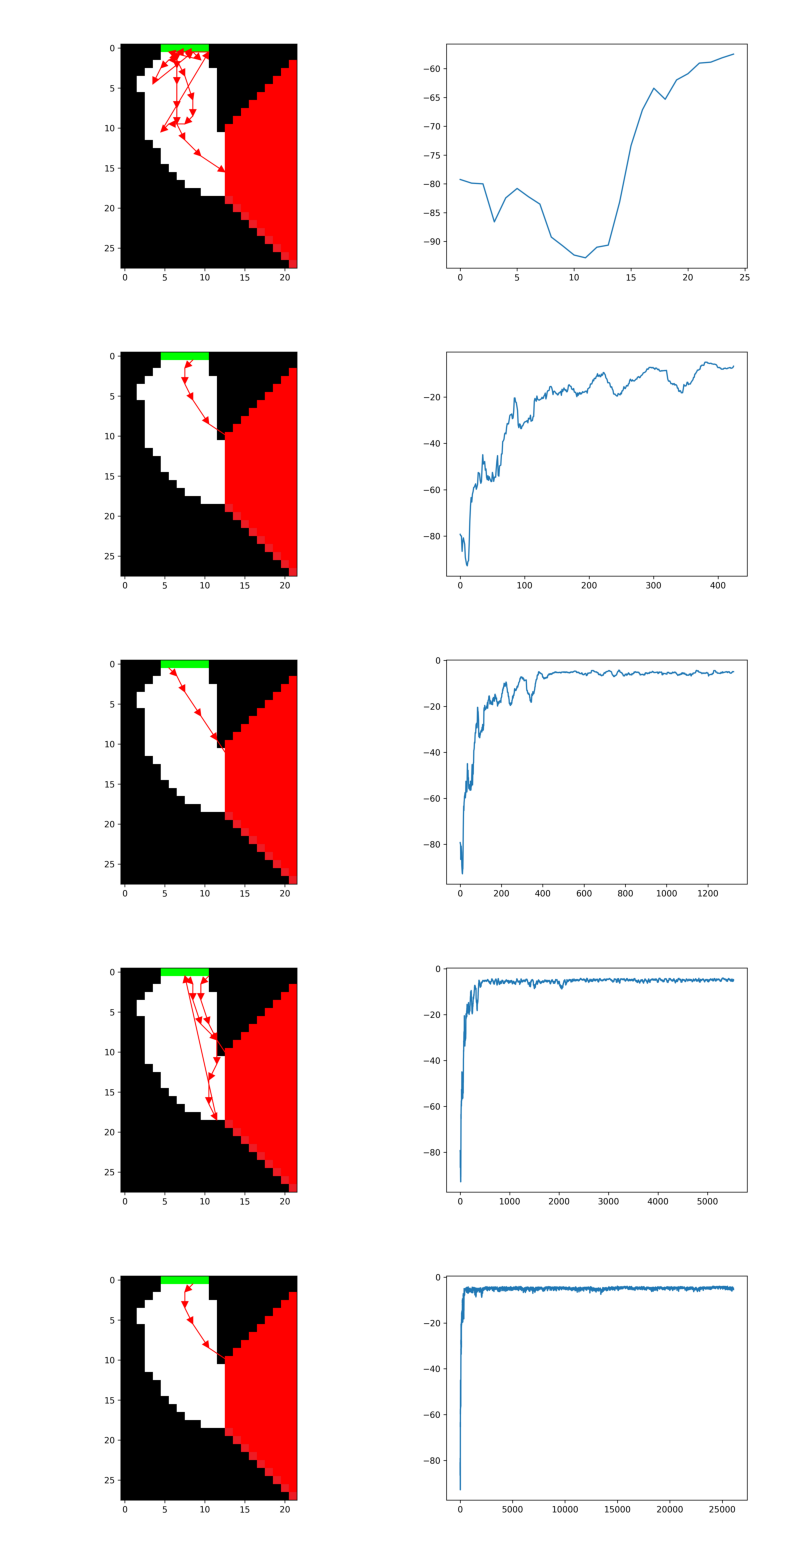

In [76]:
prefix = "greedy_rollout_corner_b"
episodes = (50, 450, 1350, 5550, 26100)

corner_b_img_matrix = []

for ep in episodes:
    corner_b_img_matrix.append([f"{prefix}/track_{ep}.png", f"{prefix}/penalties_{ep}.png"])

plot_image_matrix(corner_b_img_matrix, figsize=(10, 20))

widzimy jak funkcja kary staje się coraz stabilniejsza w kolejnych epizodach, a auto zmieża do celu po coraz prostrzej lini, przenikając nawet przez ścianę :)

### corner_c — studium $\alpha$ i $n$

`python solution.py param_study` — siatka $(n,\alpha)$ zdefiniowana w `cmd_param_study` w `solution.py` (corner, epizody, listy `n_list` / `alphas`). Wyniki dopisywane są do `plots/param_study_<corner>.csv`; po serii uruchomień skrypt może od razu wygenerować `plots/param_study_<corner>.png` (`utils.plot_param_study_n_alpha`). Sam wykres bez ponownego treningu: `python solution.py param_study_plot --param-study-corner corner_c`.

Trasy corner_c (~550 kroków w epizodzie) — **następna komórka** rysuje te same trasy w jednym rzędzie (jak siatka tor | kara powyżej).

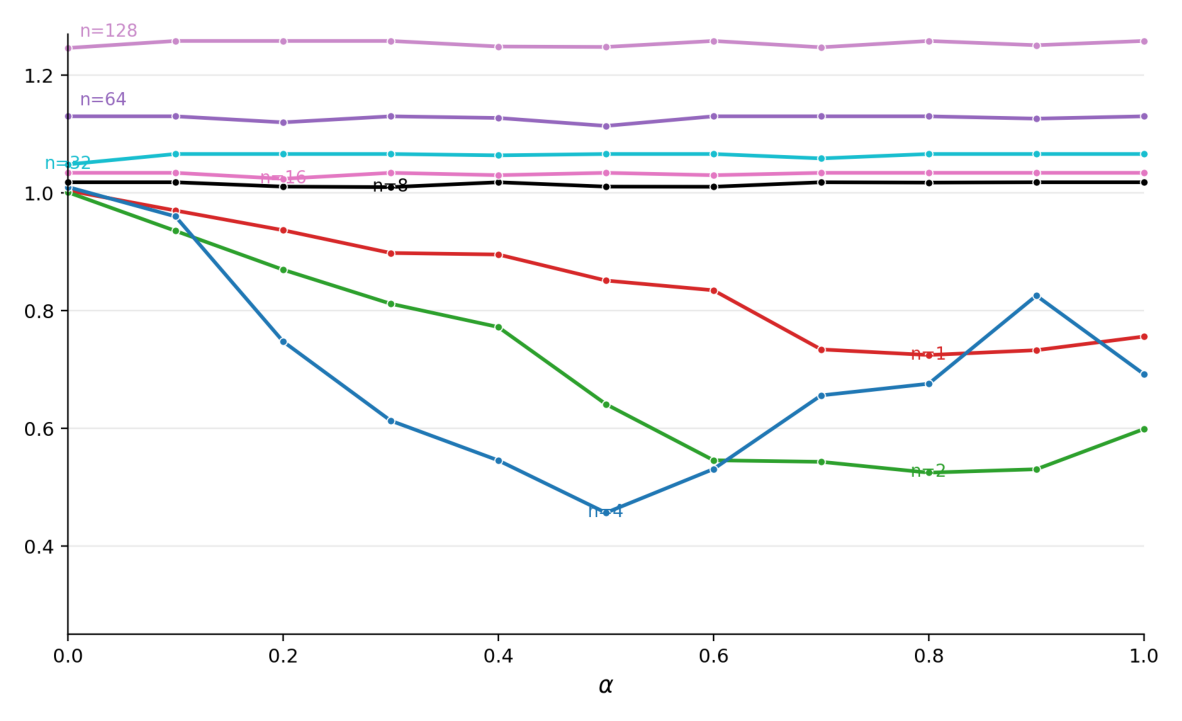

In [72]:
plot_image_matrix([[f"case_study_SUCCESS\\param_study_corner_c.png"]], figsize=(15, 15))

### corner_c - track

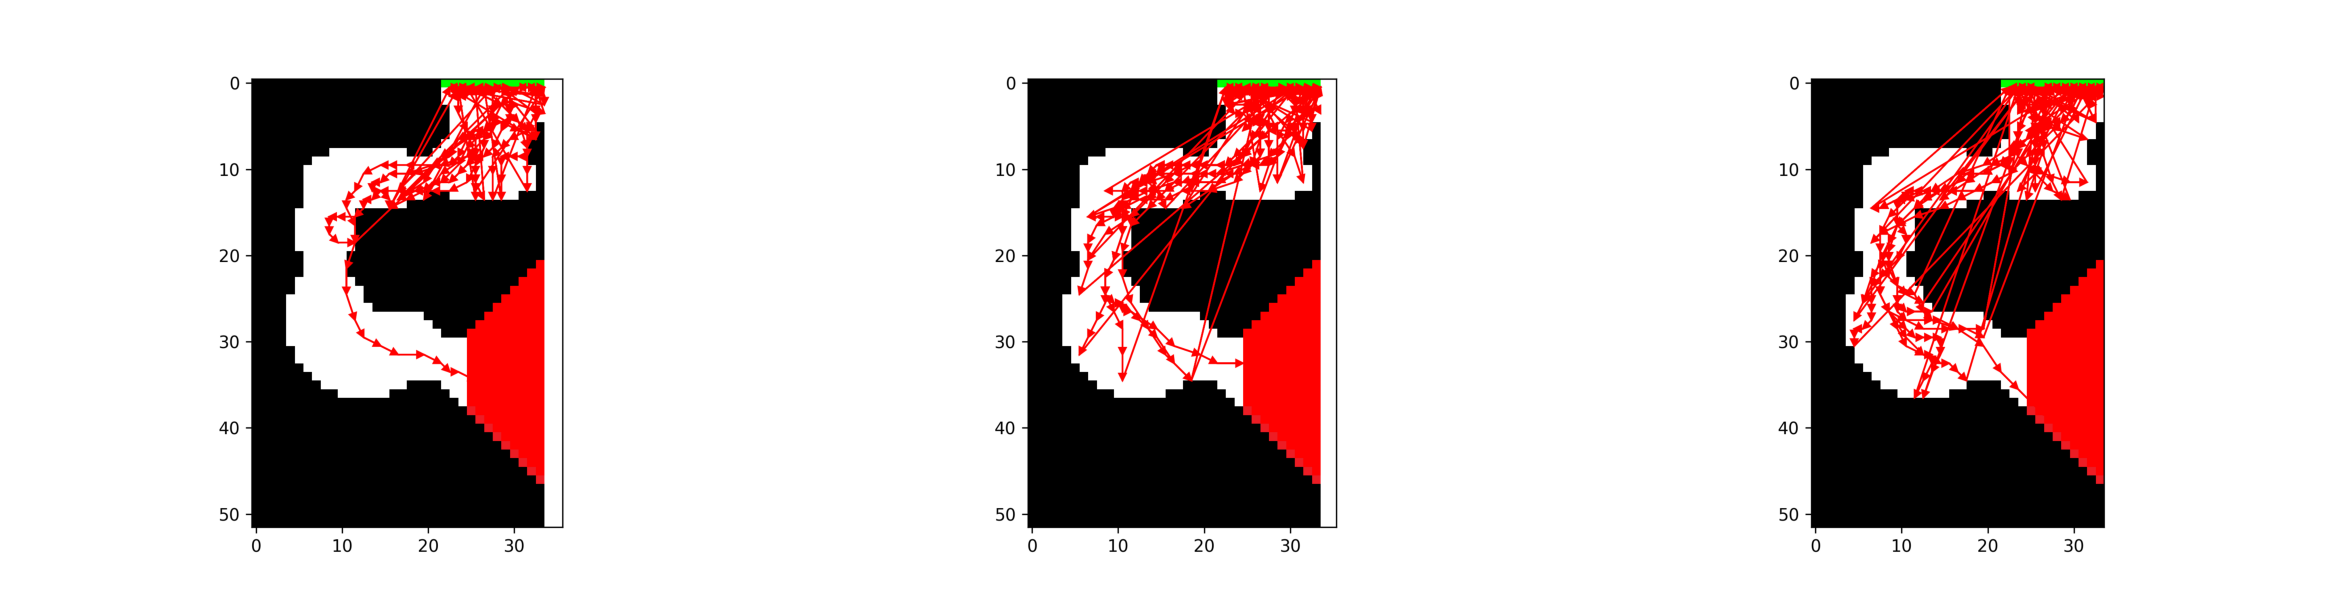

In [65]:
prefix = "corrner_c___track_550"
files = ["", "-2", "-3"]
ext = ".png"

array = []
for file in files:
    array.append(f"{prefix}{file}{ext}")

plot_image_matrix([array], figsize=(30, 30))

## corner_d

Tor trudniejszy — parametry zwykle przenoszone ze studium na corner_c ($n=4$, $\alpha=0.5$)

```python
if args.mode == "train_d":
    train_off_policy(
        "corner_d",
        40000,
        step_size=0.5,        # alpha
        step_no=4,            # sarsa-n
        experiment_rate=0.05,
        discount=1.0,
    )
```

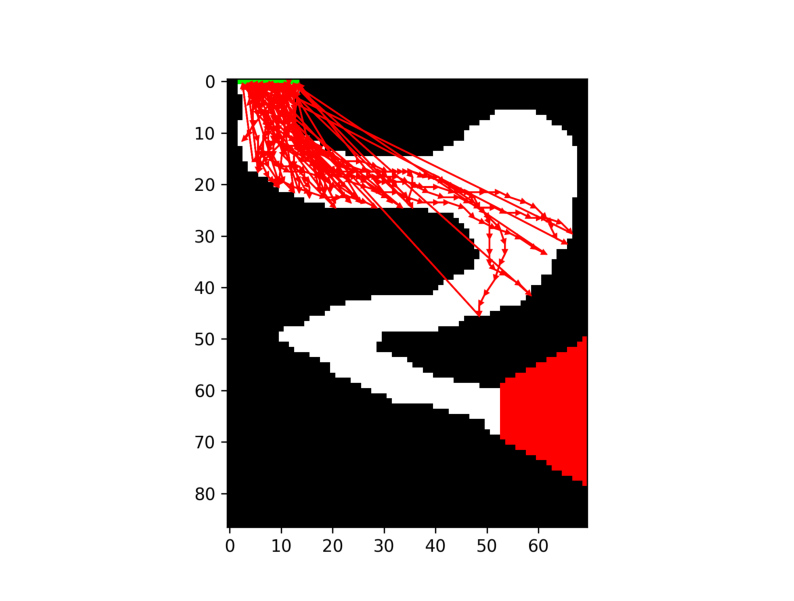

In [75]:
prefix = "corner_d/"
files = [ 550 ]
ext = ".png"

array = []
for file in files:
    array.append(f"{prefix}track_{file}{ext}")

plot_image_matrix([array], figsize=(10, 10))

## Polityka „pędzenia do przodu” (corner_c)

Zamiast samego ε-greedy mieszam rozkład: część masy idzie na akcje z największym $a_x+a_y$ (bo tak „wciska gaz”), reszta zostaje przy ε-greedy na $Q$. Parametr `push_forward_bias` to właśnie ta mieszanka.

```python
def push_forward_policy(self, state: State, actions: list[Action]) -> dict[Action, float]:
    p = self.push_forward_bias
    accel_scores = np.array([float(a.a_x + a.a_y) for a in actions])
    max_s = float(np.max(accel_scores))
    push_mask = (accel_scores == max_s).astype(float)
    push = self._normalise(push_mask)
    greedy_mix = np.array(list(self.epsilon_greedy_policy(state, actions).values()))
    probs = p * push + (1.0 - p) * greedy_mix
    ...
```

Porównanie z rozsądnym $b$: `python solution.py compare_push_is` (domyślnie corner_c; parametry: `--compare-episodes`, `--compare-alpha`, `--compare-n`, `--compare-epsilon`, `--compare-push-bias`, `--compare-corner`). U mnie w tabeli poniżej $\varepsilon$-greedy z IS był wyraźnie lepszy niż warianty z push — średnia kara w ostatnim oknie dla push schodziła do bardzo słabych wartości.

| konfiguracja | śr. kara (ostatnie 100 ep.) |
|--------------|----------------------------|
| epsilon_is | −117.03 |
| push_is | −505.0 |
| push_no_is | −505.0 |


## Wyłączenie IS przy pędzącym agencie

Wystarczy `use_importance_sampling=False` przy tworzeniu sterownika / w `train_off_policy`. Wtedy waga przy zwrocie to zawsze 1 i nie ma korekty $\pi/b$. Przy mocno innym $b$ niż $\pi$ bez IS uczymy się w praktyce na „złych” trajektoriach — u mnie przy push z IS i bez i tak wyszło źle w tym samym oknie, ale to już kwestia ustawień i liczby epizodów.



## Wnioski

- **Środowisko i algorytm:** problem zakrętu sprowadza się do n-step SARSA poza polityką: zachłanna $\pi$ na $Q$, behawioralna $\varepsilon$-greedy (albo „pędzenie”), z opcjonalnym importance sampling w wadze aktualizacji.

- **corner_b:** trening (para tor/kara dla epizodów 50, …, 26100) pokazuje **komórka kodu** z macierzą 5×2; rollout zachłanny nadal jako załączniki `track_30001+` w markdownzie.

- **corner_c — studium $(n, \alpha)$:** zależność od hiperparametrów jest wyraźna (`plots/param_study_corner_c.csv` / wykres w sekcji powyżej): przy zbyt dużym $n$ krzywe się psują; sensowny punkt to okolica **$n=4$, $\alpha=0.5$** (dla danych z mojego studium). Trasy na corner_c pokazują ten sam tor przy różnych przejazdach po wyuczeniu.

- **corner_d:** przy parametrach przeniesionych ze studium tor jest wyraźnie trudniejszy — to raczej weryfikacja niż „ładny” wynik od pierwszego strzału.

- **Polityka pędzenia:** mieszanka z preferencją dużego $a_x+a_y$ jako $b$ mocno rozjeżdża się od zachłannej $\pi$. Na corner_c w `compare_push_is` **$\varepsilon$-greedy z IS** pozostawał znośny, a warianty z **push** (z IS i bez) schodziły do praktycznie najgorszej kary w oknie — agresywne $b$ niszczy użyteczność danych w krótkim horyzoncie treningu. **Wyłączenie IS** przy push teoretycznie zabija korektę na $\pi$; w pomiarach i tak oba warianty były złe, więc główny winowajca to tu sam wybór $b$.